In [57]:
import pandas as pd
import os

log_file = "../metrics.csv"
current_dir = os.getcwd()
log_file_path = os.path.join(current_dir, log_file)

metrics = pd.read_csv(log_file_path, converters={'Dimensionality Reduction': str})

In [58]:
metrics

,Model,Dimensionality Reduction,DISCO,DBCV,DSI,Silhouette Score
0,K-means,None,0.198159,-0.976715,0.145,0.189
1,K-means,PCA,0.201910,-0.976622,0.144,0.191
2,K-means,Autoencoder,0.339286,-0.991873,0.194,0.309
3,K-means,Shap,0.198442,-0.982531,0.182,0.212
4,Hierarchical,None,-0.116067,-0.901949,0.170,-0.118
5,Hierarchical,PCA,0.288457,-0.989020,0.103,0.200
6,Hierarchical,Autoencoder,0.716868,-0.996975,0.244,0.572
7,Hierarchical,Shap,0.164392,-0.993611,0.285,0.174
8,GMM,None,0.379217,-0.993207,0.201,0.340
9,GMM,PCA,0.400048,-0.991237,0.195,0.352


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_metrics_by_model(metrics: pd.DataFrame, model: str, figsize=(10, 6)) -> None:
    """
    metrics: DataFrame containing the metrics data (Model, Dimensionality Reduction, Focus Metric, DISCO, DBCV, DSI, Silhouette Score)
    """

    df = metrics[metrics["Model"] == model][
        [
            "Dimensionality Reduction",
            "DISCO",
            "DBCV",
            "DSI",
            "Silhouette Score",
        ]
    ].copy()

    # Preparar dados para plotting
    df_melted = df.melt(
        id_vars=["Dimensionality Reduction"], 
        value_vars=["DISCO", "DBCV", "DSI", "Silhouette Score"],
        var_name="Metric",
        value_name="Value"
    )
    
    # Configurar estilo e paleta de cores profissional
    sns.set_style("whitegrid")
    palette = {
        'None': '#2E86AB',        # Azul profissional
        'PCA': '#A23B72',         # Roxo/magenta
        'Autoencoder': '#F18F01', # Laranja vibrante
        'Shap': '#C73E1D',         # Vermelho terra
        'Shap-Autoencoder': '#6A4C93'      # Roxo escuro
    }
    
    # Criar figura e eixo
    fig, ax = plt.subplots(figsize=figsize)
    
    # Criar o gráfico de barras
    bar_plot = sns.barplot(
        data=df_melted, 
        x="Metric", 
        y="Value", 
        hue="Dimensionality Reduction",
        palette=palette,
        ax=ax,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )
    
    # Adicionar linha horizontal em y=0 para referência
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1.2, alpha=0.3)
    
    # Adicionar valores nas barras
    for container in bar_plot.containers:
        bar_plot.bar_label(
            container, 
            fmt='%.3f',
            padding=3,
            fontsize=9,
            weight='bold'
        )
    
    # Customizar título
    ax.set_title(
        f'Comparação de Métricas de Clustering para {model}',
        fontsize=16,
        fontweight='bold',
        pad=20
    )
    
    # Remove o xlabel padrão - vamos adicionar manualmente
    ax.set_xlabel('')
    ax.set_ylabel('Valor da Métrica', fontsize=13, fontweight='bold')
    
    # Melhorar grid
    ax.grid(True, axis='y', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    
    # Customizar ticks
    ax.tick_params(axis='both', which='major', labelsize=11)
    
    # Melhorar legenda
    legend = ax.legend(
        title='Redução de\nDimensionalidade',
        title_fontsize=11,
        fontsize=10,
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        frameon=True,
        shadow=True,
        fancybox=True
    )
    legend.get_title().set_fontweight('bold')
    
    # Ajustar ylim para fazer espaço para as anotações
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max + 0.05 * abs(y_max - y_min))
    
    # Adicionar anotações interpretativas abaixo das métricas
    metric_info = {
        'DISCO': 'Baseado em Densidade\n(maior é melhor)',
        'DBCV': 'Baseado em Densidade\n(maior é melhor)',
        'DSI': 'Separação\n(maior é melhor)',
        'Silhouette Score': 'Coesão\n(maior é melhor)'
    }
    
    for i, (metric, info) in enumerate(metric_info.items()):
        ax.text(
            i, -0.08, info,
            ha='center', va='top',
            fontsize=8,
            style='italic',
            color='gray',
            transform=ax.get_xaxis_transform()
        )
    
    # Adicionar "Clustering Metric" label ainda mais abaixo
    fig.text(
        0.5, 0.05, 'Métrica de Clustering',
        ha='center', va='bottom',
        fontsize=13,
        fontweight='bold',
        transform=fig.transFigure
    )
    
    # Ajustar layout para acomodar todas as anotações
    plt.subplots_adjust(bottom=0.2)
    
    plt.show()

In [60]:
def plot_metrics_by_dr(metrics: pd.DataFrame, dr_method: str, figsize=(10, 6)) -> None:
    """
    metrics: DataFrame containing the metrics data (Model, Dimensionality Reduction, Focus Metric, DISCO, DBCV, DSI, Silhouette Score)
    """

    df = metrics[metrics["Dimensionality Reduction"] == dr_method][
        [
            "Model",
            "DISCO",
            "DBCV",
            "DSI",
            "Silhouette Score",
        ]
    ].copy()

    # Preparar dados para plotting
    df_melted = df.melt(
        id_vars=["Model"], 
        value_vars=["DISCO", "DBCV", "DSI", "Silhouette Score"],
        var_name="Metric",
        value_name="Value"
    )

    df_melted["Metric"] = df_melted["Metric"].apply(lambda x: x.center(18))

    # Configurar estilo e paleta de cores profissional
    sns.set_style("whitegrid")
    palette = {
        'K-means': '#F18F01',        # Laranja vibrante
        'Hierarchical': '#6A4C93',   # Roxo escuro
        'GMM': '#FF6F61',           # Coral
        'Spectral': '#88B04B',      # Verde oliva
        'DBSCAN': '#C73E1D',         # Vermelho terra
        'HDBSCAN': '#2E86AB',        # Azul profissional
        'SHADE': '#A23B72',         # Roxo/magenta
    }

    # Criar figura e eixo
    fig, ax = plt.subplots(figsize=figsize)

    # Criar o gráfico de barras horizontal
    bar_plot = sns.barplot(
        data=df_melted, 
        x="Value", 
        y="Metric", 
        hue="Model",
        palette=palette,
        ax=ax,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )
    
    # Adicionar linha horizontal em x=0 para referência
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)

    # Adicionar valores nas barras
    for container in bar_plot.containers:
        bar_plot.bar_label(
            container, 
            fmt='%.3f',
            padding=3,
            fontsize=8,
            weight='bold'
        )

    # Customizar título
    ax.set_title(
        f'Comparação de Métricas de Clustering para {dr_method} Redução da Dimensionalidade',
        fontsize=16,
        fontweight='bold',
        pad=20
    )

    # Remove o xlabel padrão - vamos adicionar manualmente
    ax.set_xlabel('Valor da Métrica', fontsize=13, fontweight='bold')
    ax.set_ylabel('Métrica de Clustering', fontsize=13, fontweight='bold')

    # Melhorar grid
    ax.grid(True, axis='x', alpha=0.3, linestyle='--', linewidth=0.7)
    ax.set_axisbelow(True)
    # Customizar ticks
    ax.tick_params(axis='both', which='major', labelsize=11)
    # Melhorar legenda
    legend = ax.legend(
        title='Algoritmo de\nClustering',
        title_fontsize=11,
        fontsize=9,
        loc='upper left',
        bbox_to_anchor=(1.02, 1),
        frameon=True,
        shadow=True,
        fancybox=True
    )
    legend.get_title().set_fontweight('bold')

    # Ajustar ylim para fazer espaço para as anotações
    y_min, y_max = ax.get_xlim()
    ax.set_xlim(y_min - 0.05 * abs(y_max - y_min), y_max + 0.05 * abs(y_max - y_min))

    # Adicionar anotações interpretativas abaixo das métricas
    metric_info = {
        'DISCO': 'Baseado em Densidade\n(maior é melhor)',
        'DBCV': 'Baseado em Densidade\n(maior é melhor)',
        'DSI': 'Separação\n(maior é melhor)',
        'Silhouette Score': 'Coesão\n(maior é melhor)'
    }

    for i, (metric, info) in enumerate(metric_info.items()):
        ax.text(
            - 0.08, i + 0.15, info,
            ha='center', va='top',
            fontsize=8,
            style='italic',
            color='gray',
            transform=ax.get_yaxis_transform()
        )

    # Adicionar "Métrica de Clustering" label ainda mais abaixo
    # fig.text(
    #     0.5, 0.05, 'Métrica de Clustering',
    #     ha='center', va='bottom',
    #     fontsize=13,
    #     fontweight='bold',
    #     transform=fig.transFigure
    # )

    # Ajustar layout para acomodar todas as anotações
    plt.subplots_adjust(bottom=0.15)
    plt.show()

In [61]:
def plot_overall_metrics_by_model(
    metrics: pd.DataFrame, figsize=(12, 8), format: str = "barplot"
) -> None:
    """
    Plota um gráfico de barras comparando as métricas de clustering para todos os modelos e métodos de redução de dimensionalidade.
    metrics: DataFrame contendo os dados das métricas (Model, Dimensionality Reduction, Focus Metric, DISCO, DBCV, DSI, Silhouette Score)
    """

    # Preparar dados para plotting
    df_melted = metrics.melt(
        id_vars=["Model", "Dimensionality Reduction"],
        value_vars=["DISCO", "DBCV", "DSI", "Silhouette Score"],
        var_name="Metric",
        value_name="Value",
    ).copy()

    df_melted = df_melted.groupby(['Metric', 'Model'])['Value'].mean().reset_index()

    ordered_metrics = ["DISCO", "DBCV", "DSI", "Silhouette Score"]
    ordered_models = ["K-means", "GMM", "Hierarchical", "DBSCAN", "Spectral", "HDBSCAN", "SHADE"]

    # Sort indexes of df_melted based on the defined order
    df_melted['Metric'] = pd.Categorical(df_melted['Metric'], categories=ordered_metrics, ordered=True)
    df_melted['Model'] = pd.Categorical(df_melted['Model'], categories=ordered_models, ordered=True)
    df_melted = df_melted.sort_values(['Metric', 'Model'])

    df_melted["Metric"] = df_melted["Metric"].apply(lambda x: x.center(20))

    # Configurar estilo e paleta de cores profissional
    sns.set_style("whitegrid")
    palette = {
        "K-means": "#2E86AB",  # Azul profissional
        "GMM": "#A23B72",  # Roxo/magenta
        "Hierarchical": "#F18F01",  # Laranja vibrante
        "DBSCAN": "#C73E1D",  # Vermelho terra
        "Spectral": "#6A4C93",  # Roxo escuro
        "HDBSCAN": "#117A65",  # Verde escuro
        "SHADE": "#CCB342",  # Laranja escuro
    }

    # Criar figura e eixo
    fig, ax = plt.subplots(figsize=figsize)

    # Criar o gráfico de barras
    if format == "boxplot":
        bar_plot = sns.boxplot(
            data=df_melted,
            x="Value",
            y="Metric",
            hue="Model",
            palette=palette,
            ax=ax,
        )
    else:
        bar_plot = sns.barplot(
            data=df_melted,
            x="Value",
            y="Metric",
            hue="Model",
            palette=palette,
            ax=ax,
            edgecolor="black",
            linewidth=0.8,
            alpha=0.85,
        )

    # Adicionar linha horizontal em y=0 para referência
    ax.axvline(x=0, color="black", linestyle="-", linewidth=1.2, alpha=0.3)

    #  Adicionar valores nas barras se for barplot
    if format == "barplot":
        for container in bar_plot.containers:
            bar_plot.bar_label(
                container, fmt="%.3f", padding=3, fontsize=9, weight="bold"
            )

    # Customizar título
    ax.set_title(
        "Comparação de Métricas de Clustering",
        fontsize=16,
        fontweight="bold",
    )

    # Remove o xlabel padrão - vamos adicionar manualmente
    ax.set_xlabel("Valor da Métrica", fontsize=13, fontweight="bold")
    ax.set_ylabel("Métrica de Clustering", fontsize=13, fontweight="bold")

    # Melhorar grid
    ax.grid(True, axis="x", alpha=0.3, linestyle="--", linewidth=0.7)
    ax.set_axisbelow(True)

    # Customizar ticks
    ax.tick_params(axis="both", which="major", labelsize=11)

    # Melhorar legenda
    legend = ax.legend(
        title="Algoritmo de\nClustering",
        title_fontsize=11,
        fontsize=10,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=True,
        shadow=True,
        fancybox=True,
    )
    legend.get_title().set_fontweight("bold")

    # Ajustar ylim para fazer espaço para as anotações
    x_min, x_max = ax.get_xlim()
    ax.set_xlim(x_min - 0.05 * abs(x_max - x_min), x_max + 0.05 * abs(x_max - x_min))

    # Adicionar anotações interpretativas abaixo das métricas
    metric_info = {
        "DISCO": "Baseado em Densidade\n(maior é melhor)",
        "DBCV": "Baseado em Densidade\n(maior é melhor)",
        "DSI": "Separação\n(maior é melhor)",
        "Silhouette Score": "Coesão\n(maior é melhor)",
    }

    for i, (metric, info) in enumerate(metric_info.items()):
        ax.text(
            - 0.07, i + 0.15, info,
            ha='center', va='top',
            fontsize=8,
            style='italic',
            color='gray',
            transform=ax.get_yaxis_transform()
        )

    # Adicionar "Clustering Metric" label ainda mais abaixo
    # fig.text(
    #     0.5,
    #     0.13,
    #     "Clustering Metric",
    #     ha="center",
    #     va="bottom",
    #     fontsize=13,
    #     fontweight="bold",
    #     transform=fig.transFigure,
    # )

    # Ajustar layout para acomodar todas as anotações
    plt.subplots_adjust(bottom=0.2)
    plt.show()

In [62]:
def plot_overall_metrics_by_dr(
    metrics: pd.DataFrame, figsize=(12, 8), format: str = "barplot"
) -> None:
    """
    Plota um gráfico de barras comparando as métricas de clustering para todos os modelos e métodos de redução de dimensionalidade.
    metrics: DataFrame contendo os dados das métricas (Model, Dimensionality Reduction, Focus Metric, DISCO, DBCV, DSI, Silhouette Score)
    """

    # Preparar dados para plotting
    df_melted = metrics.melt(
        id_vars=["Model", "Dimensionality Reduction"],
        value_vars=["DISCO", "DBCV", "DSI", "Silhouette Score"],
        var_name="Metric",
        value_name="Value",
    ).copy()

    df_melted = df_melted.groupby(['Metric', 'Dimensionality Reduction'])['Value'].mean().reset_index()

    ordered_metrics = ["DISCO", "DBCV", "DSI", "Silhouette Score"]
    ordered_dimensionality_reductions = ["None", "PCA", "Autoencoder", "Shap"]

    # Sort indexes of df_melted based on the defined order
    df_melted['Metric'] = pd.Categorical(df_melted['Metric'], categories=ordered_metrics, ordered=True)
    df_melted['Dimensionality Reduction'] = pd.Categorical(df_melted['Dimensionality Reduction'], categories=ordered_dimensionality_reductions, ordered=True)
    df_melted = df_melted.sort_values(['Metric', 'Dimensionality Reduction'])

    # Configurar estilo e paleta de cores profissional
    sns.set_style("whitegrid")
    palette = {
        "None": "#2E86AB",  # Azul profissional
        "PCA": "#A23B72",  # Roxo/magenta
        "Autoencoder": "#F18F01",  # Laranja vibrante
        "Shap": "#C73E1D",  # Vermelho terra
    }

    # Criar figura e eixo
    fig, ax = plt.subplots(figsize=figsize)

    # Criar o gráfico de barras
    if format == "boxplot":
        bar_plot = sns.boxplot(
            data=df_melted,
            x="Metric",
            y="Value",
            hue="Dimensionality Reduction",
            palette=palette,
            ax=ax,
        )
    else:
        bar_plot = sns.barplot(
            data=df_melted,
            x="Metric",
            y="Value",
            hue="Dimensionality Reduction",
            palette=palette,
            ax=ax,
            edgecolor="black",
            linewidth=0.8,
            alpha=0.85,
        )

    # Adicionar linha horizontal em y=0 para referência
    ax.axhline(y=0, color="black", linestyle="-", linewidth=1.2, alpha=0.3)

    #  Adicionar valores nas barras se for barplot
    if format == "barplot":
        for container in bar_plot.containers:
            bar_plot.bar_label(
                container, fmt="%.3f", padding=3, fontsize=9, weight="bold"
            )

    # Customizar título
    ax.set_title(
        "Comparação de Métricas de Clustering",
        fontsize=16,
        fontweight="bold",
    )

    # Remove o xlabel padrão - vamos adicionar manualmente
    ax.set_xlabel("")
    ax.set_ylabel("Valor da Métrica", fontsize=13, fontweight="bold")

    # Melhorar grid
    ax.grid(True, axis="y", alpha=0.3, linestyle="--", linewidth=0.7)
    ax.set_axisbelow(True)

    # Customizar ticks
    ax.tick_params(axis="both", which="major", labelsize=11)

    # Melhorar legenda
    legend = ax.legend(
        title="Redução de\nDimensionalidade",
        title_fontsize=11,
        fontsize=10,
        loc="upper left",
        bbox_to_anchor=(1.02, 1),
        frameon=True,
        shadow=True,
        fancybox=True,
    )
    legend.get_title().set_fontweight("bold")

    # Ajustar ylim para fazer espaço para as anotações
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min, y_max + 0.05 * abs(y_max - y_min))

    # Adicionar anotações interpretativas abaixo das métricas
    metric_info = {
        "DISCO": "Baseado em Densidade\n(maior é melhor)",
        "DBCV": "Baseado em Densidade\n(maior é melhor)",
        "DSI": "Separação\n(maior é melhor)",
        "Silhouette Score": "Coesão\n(maior é melhor)",
    }

    for i, (metric, info) in enumerate(metric_info.items()):
        ax.text(
            i,
            -0.06,
            info,
            ha="center",
            va="top",
            fontsize=8,
            style="italic",
            color="gray",
            transform=ax.get_xaxis_transform(),
        )

    # Adicionar "Clustering Metric" label ainda mais abaixo
    fig.text(
        0.5,
        0.09,
        "Métrica de Clustering",
        ha="center",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        transform=fig.transFigure,
    )

    # Ajustar layout para acomodar todas as anotações
    plt.subplots_adjust(bottom=0.2)
    plt.show()

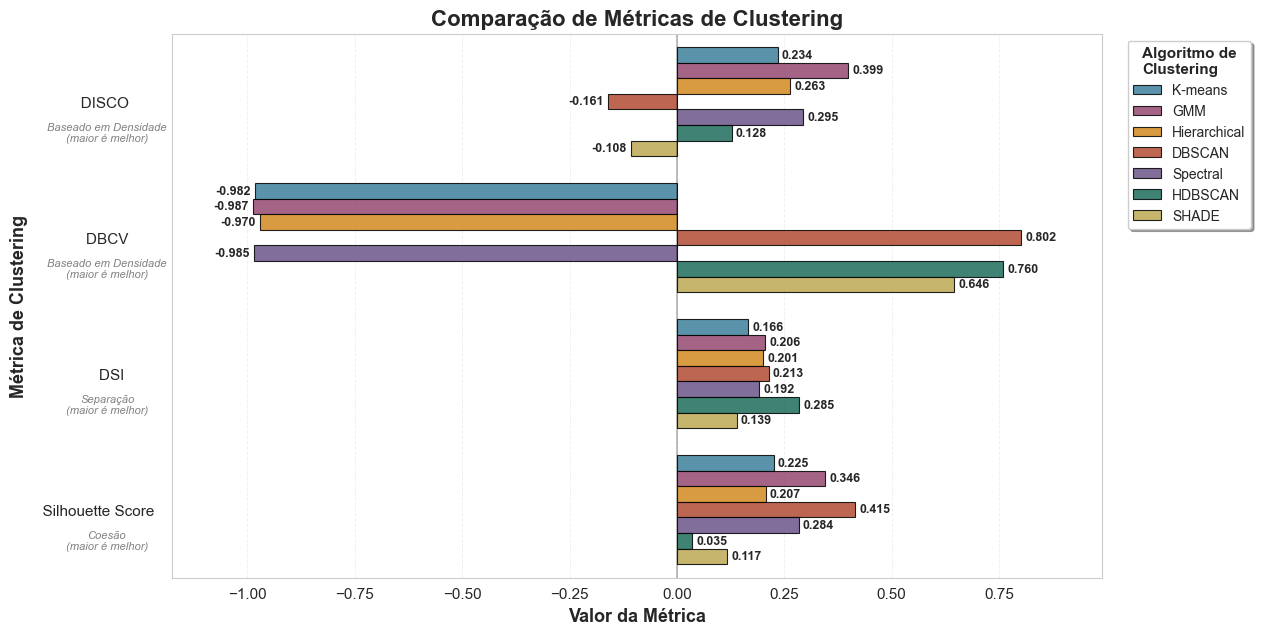

In [63]:
plot_overall_metrics_by_model(metrics)

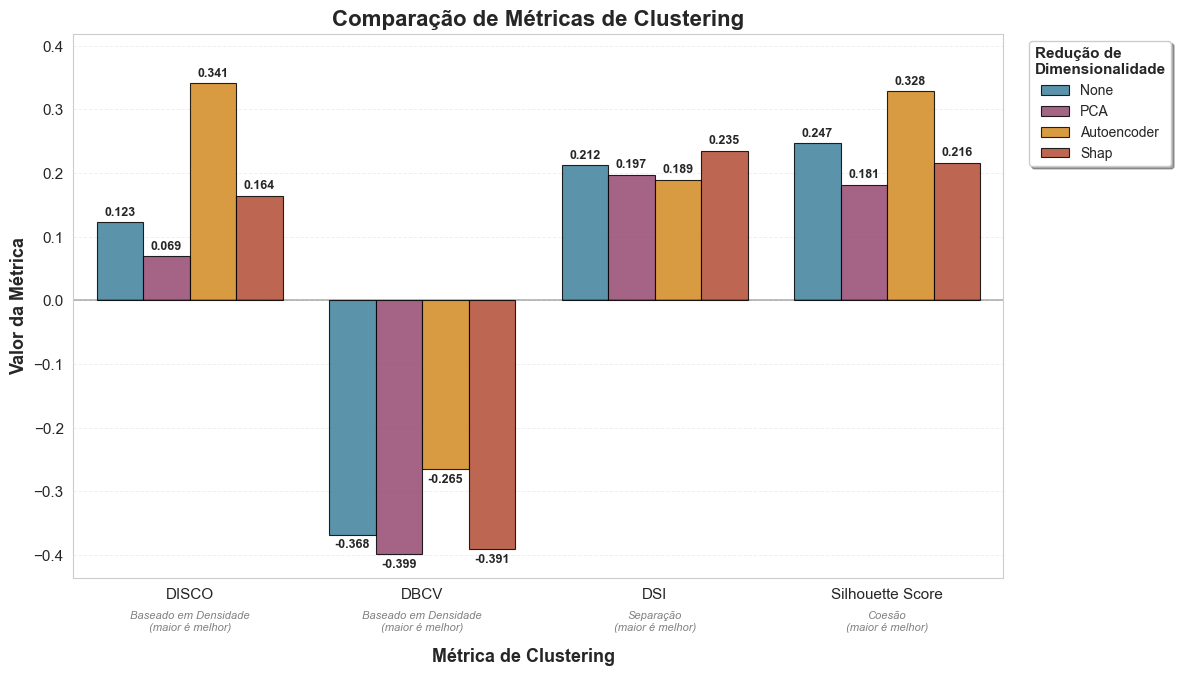

In [64]:
plot_overall_metrics_by_dr(metrics)

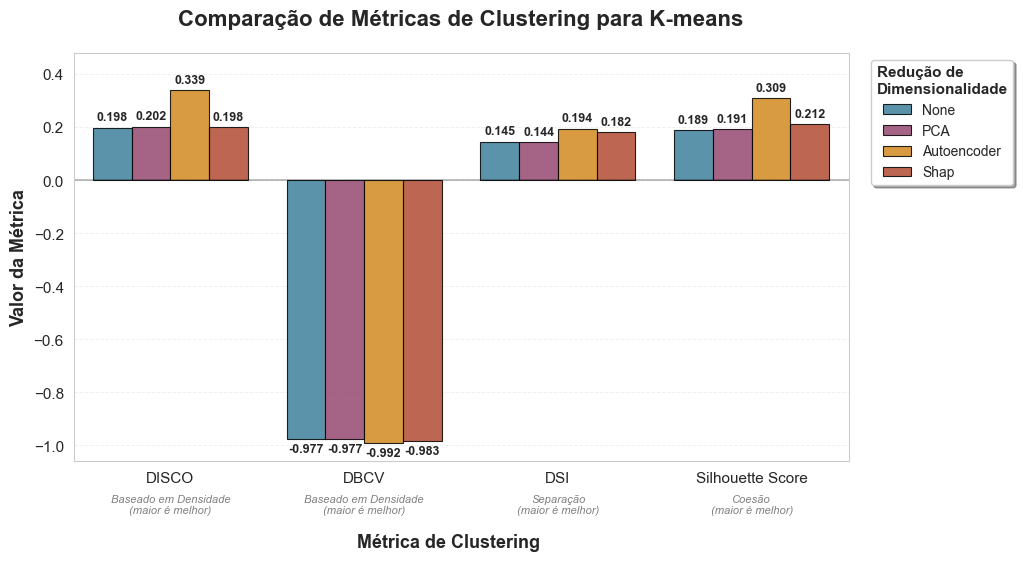

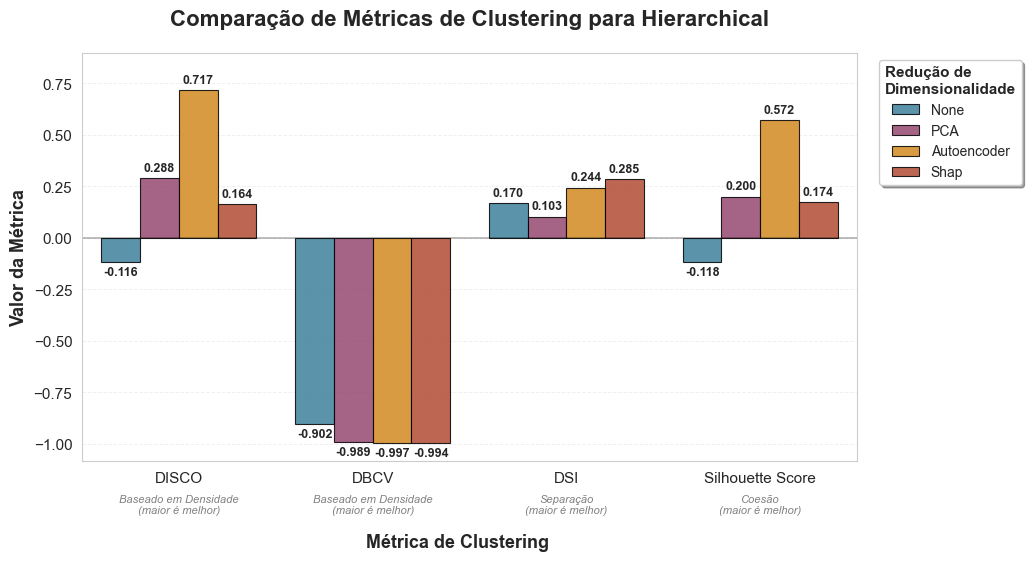

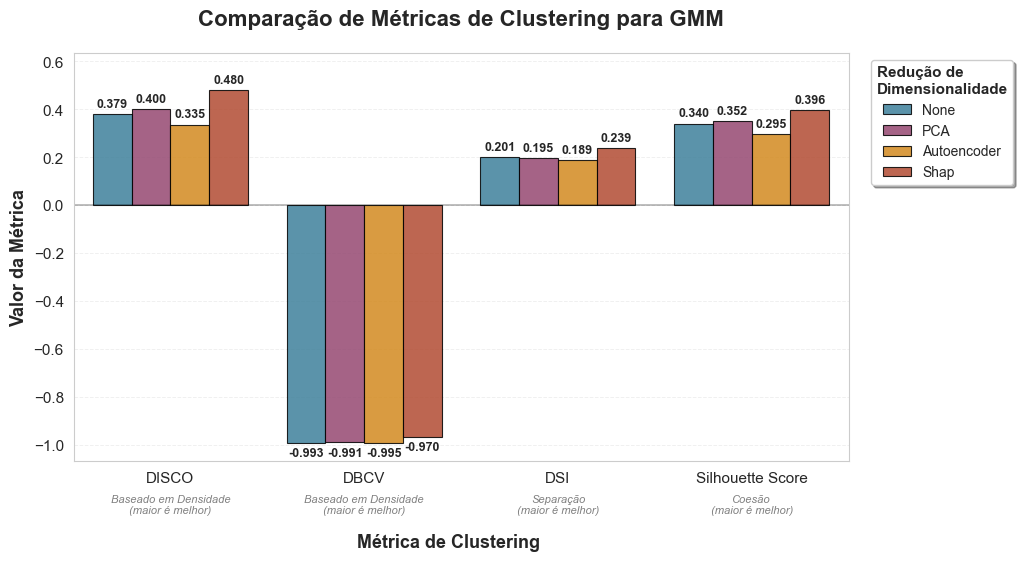

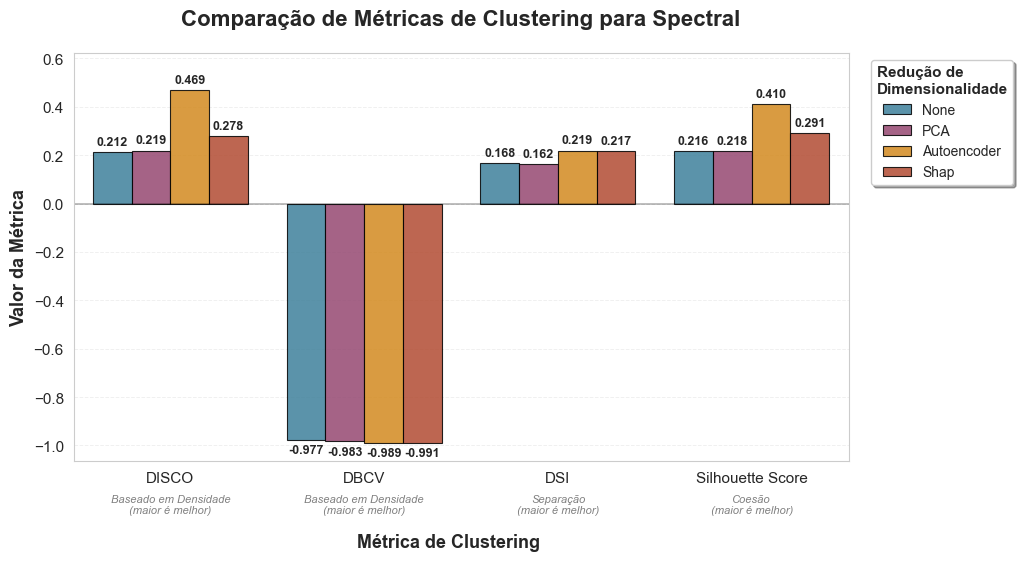

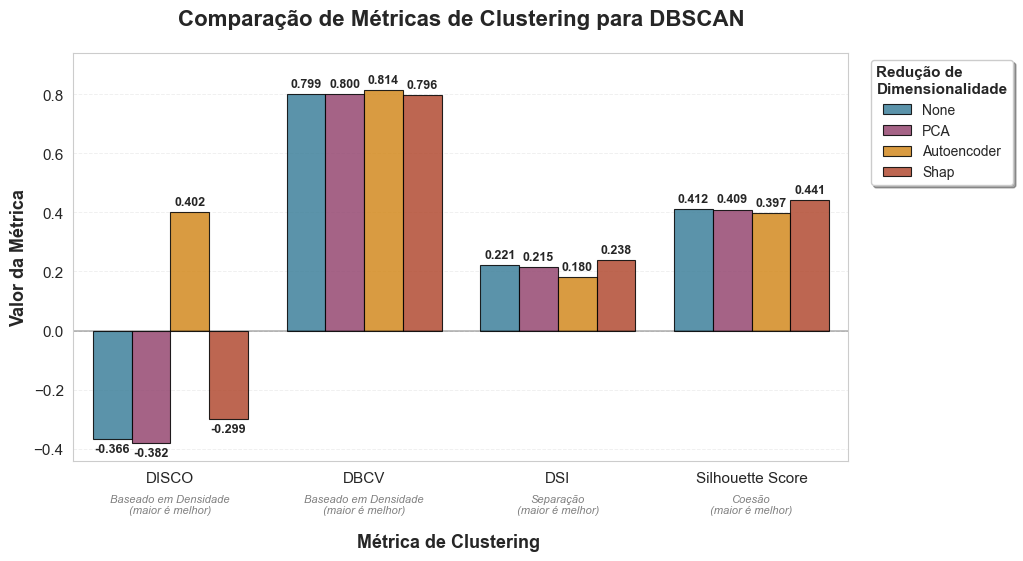

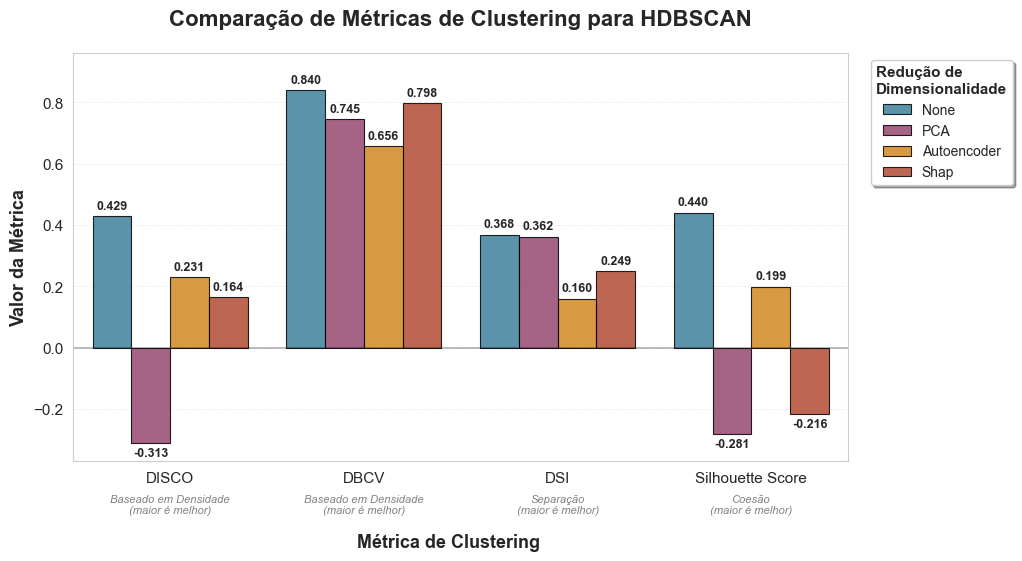

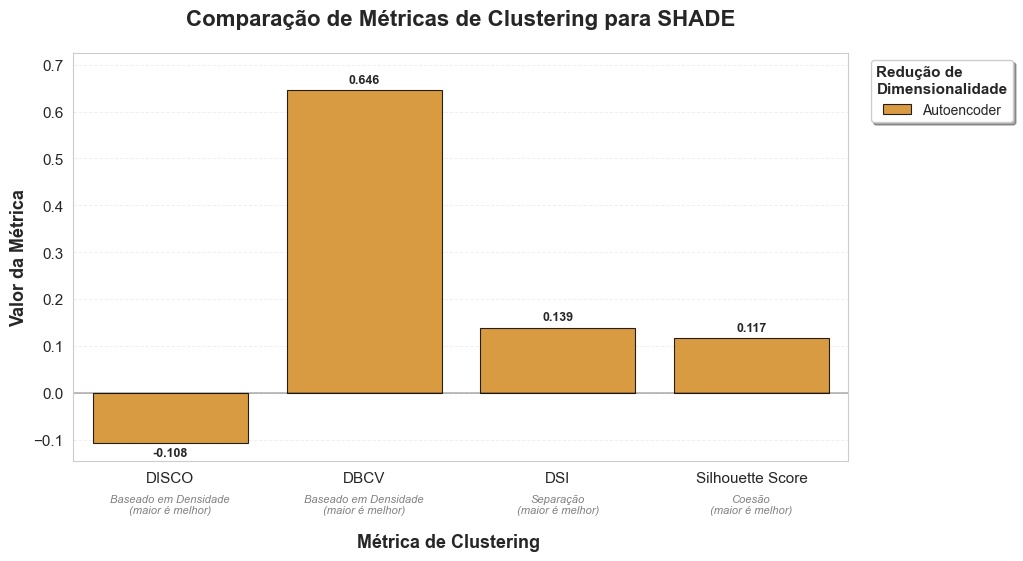

In [65]:
for model in metrics["Model"].unique():

    plot_metrics_by_model(metrics, model=model)

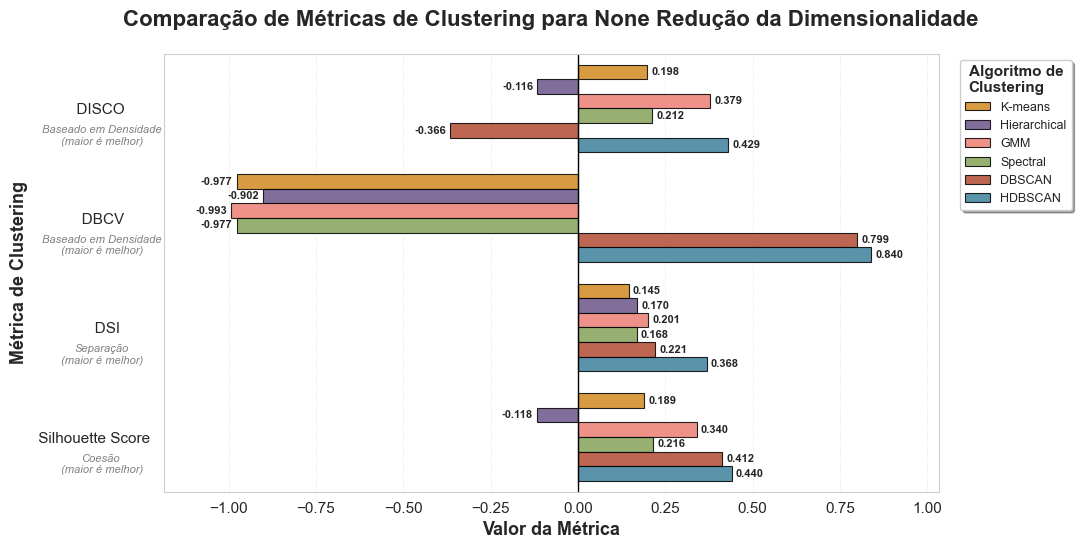

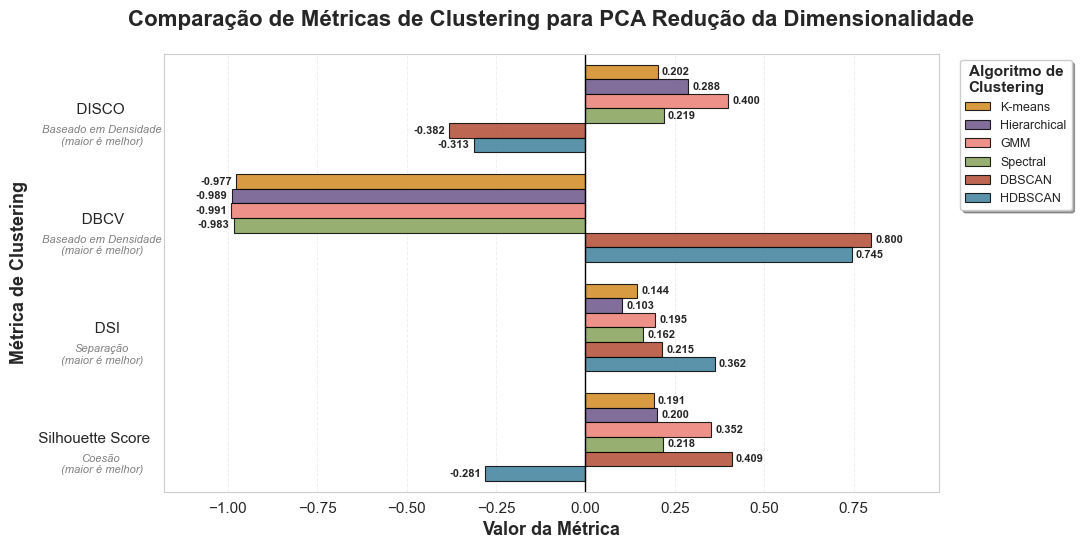

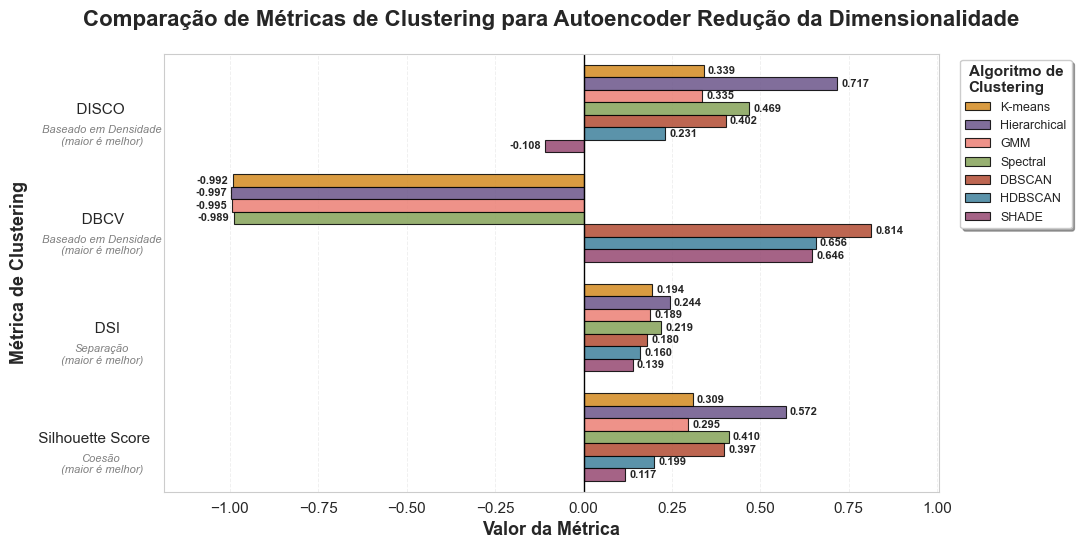

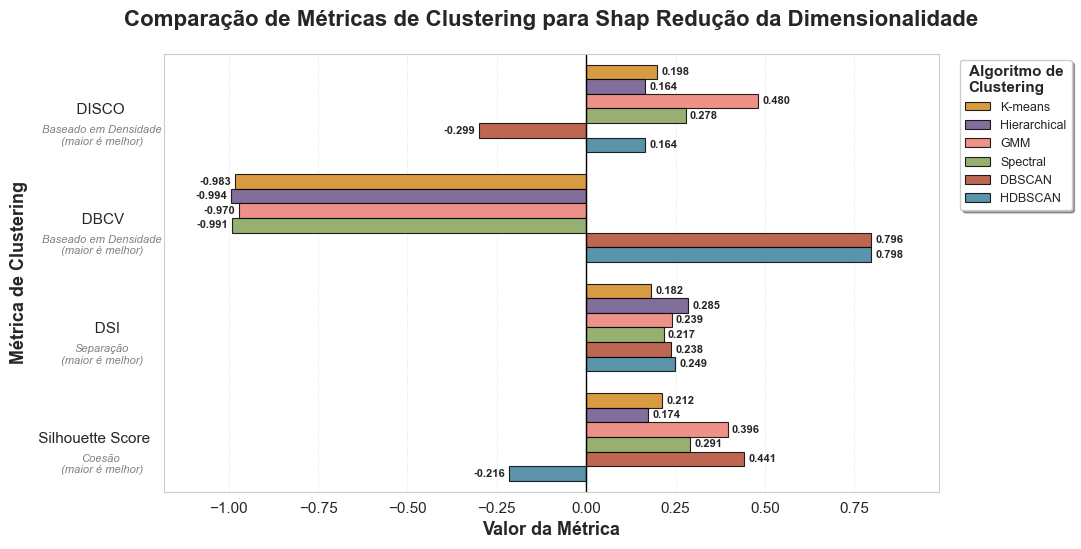

In [66]:
for dr_method in metrics["Dimensionality Reduction"].unique():

    plot_metrics_by_dr(metrics, dr_method=dr_method)

In [67]:
best_metrics = metrics[(metrics['DISCO'] > 0.4) & (metrics['DBCV'] > 0.6)]

# Add first row from original dataframe
best_metrics = pd.concat([metrics.iloc[[0]], best_metrics]).reset_index(drop=True)
best_metrics

,Model,Dimensionality Reduction,DISCO,DBCV,DSI,Silhouette Score
0,K-means,None,0.198159,-0.976715,0.145,0.189
1,DBSCAN,Autoencoder,0.401877,0.814008,0.180,0.397
2,HDBSCAN,None,0.429063,0.839940,0.368,0.440


In [68]:
# Preparar dados para plotting
df_melted = best_metrics.melt(
    id_vars=["Model", "Dimensionality Reduction"],
    value_vars=["DISCO", "DBCV", "DSI", "Silhouette Score"],
    var_name="Metric",
    value_name="Value",
).copy()

df_melted['Config'] = df_melted['Model'] + "\n" + df_melted['Dimensionality Reduction']
df_melted.drop(columns=['Model', 'Dimensionality Reduction'], inplace=True)
df_melted

,Metric,Value,Config
0,DISCO,0.198159,K-means\nNone
1,DISCO,0.401877,DBSCAN\nAutoencoder
2,DISCO,0.429063,HDBSCAN\nNone
3,DBCV,-0.976715,K-means\nNone
4,DBCV,0.814008,DBSCAN\nAutoencoder
5,DBCV,0.839940,HDBSCAN\nNone
6,DSI,0.145000,K-means\nNone
7,DSI,0.180000,DBSCAN\nAutoencoder
8,DSI,0.368000,HDBSCAN\nNone
9,Silhouette Score,0.189000,K-means\nNone


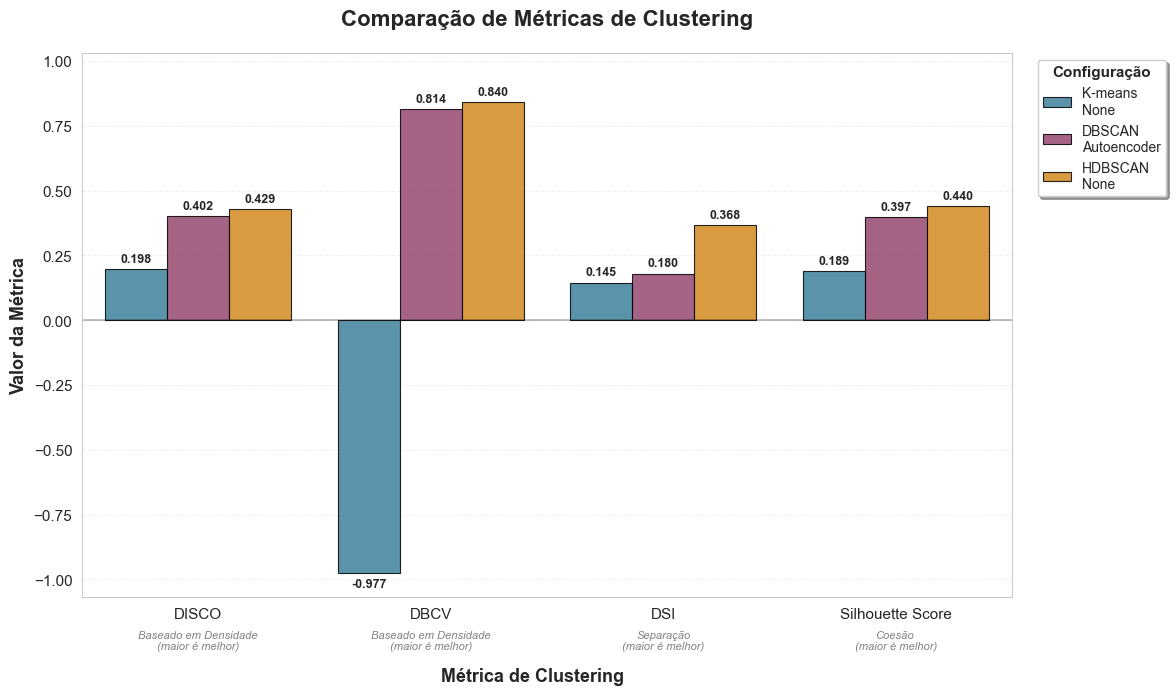

In [69]:
# Preparar dados para plotting
df_melted = best_metrics.melt(
    id_vars=["Model", "Dimensionality Reduction"],
    value_vars=["DISCO", "DBCV", "DSI", "Silhouette Score"],
    var_name="Metric",
    value_name="Value",
).copy()

df_melted["Config"] = df_melted["Model"] + "\n" + df_melted["Dimensionality Reduction"]
df_melted.drop(columns=["Model", "Dimensionality Reduction"], inplace=True)

# Configurar estilo e paleta de cores profissional
sns.set_style("whitegrid")
palette = {
    "K-means\nNone": "#2E86AB",  # Azul profissional
    "DBSCAN\nAutoencoder": "#A23B72",  # Roxo/magenta
    "HDBSCAN\nNone": "#F18F01",  # Laranja vibrante
}

# Criar figura e eixo
fig, ax = plt.subplots(figsize=(12, 8))

bar_plot = sns.barplot(
    data=df_melted,
    x="Metric",
    y="Value",
    hue="Config",
    palette=palette,
    ax=ax,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.85,
)

for container in bar_plot.containers:
    bar_plot.bar_label(
        container, fmt="%.3f", padding=3, fontsize=9, weight="bold"
    )

# Adicionar linha horizontal em y=0 para referência
ax.axhline(y=0, color="black", linestyle="-", linewidth=1.2, alpha=0.3)

#  Adicionar valores nas barras se for barplot
if format == "barplot":
    for container in bar_plot.containers:
        bar_plot.bar_label(container, fmt="%.3f", padding=3, fontsize=9, weight="bold")

# Customizar título
ax.set_title(
    "Comparação de Métricas de Clustering",
    fontsize=16,
    fontweight="bold",
    pad=20,
)

# Remove o xlabel padrão - vamos adicionar manualmente
ax.set_xlabel("")
ax.set_ylabel("Valor da Métrica", fontsize=13, fontweight="bold")

# Melhorar grid
ax.grid(True, axis="y", alpha=0.3, linestyle="--", linewidth=0.7)
ax.set_axisbelow(True)

# Customizar ticks
ax.tick_params(axis="both", which="major", labelsize=11)

# Melhorar legenda
legend = ax.legend(
    title="Configuração",
    title_fontsize=11,
    fontsize=10,
    loc="upper left",
    bbox_to_anchor=(1.02, 1),
    frameon=True,
    shadow=True,
    fancybox=True,
)
legend.get_title().set_fontweight("bold")

# Ajustar ylim para fazer espaço para as anotações
y_min, y_max = ax.get_ylim()
ax.set_ylim(y_min, y_max + 0.05 * abs(y_max - y_min))

# Adicionar anotações interpretativas abaixo das métricas
metric_info = {
    "DISCO": "Baseado em Densidade\n(maior é melhor)",
    "DBCV": "Baseado em Densidade\n(maior é melhor)",
    "DSI": "Separação\n(maior é melhor)",
    "Silhouette Score": "Coesão\n(maior é melhor)",
}

for i, (metric, info) in enumerate(metric_info.items()):
    ax.text(
        i,
        -0.06,
        info,
        ha="center",
        va="top",
        fontsize=8,
        style="italic",
        color="gray",
        transform=ax.get_xaxis_transform(),
    )

# Adicionar "Clustering Metric" label ainda mais abaixo
fig.text(
    0.5,
    0.09,
    "Métrica de Clustering",
    ha="center",
    va="bottom",
    fontsize=13,
    fontweight="bold",
    transform=fig.transFigure,
)

# Ajustar layout para acomodar todas as anotações
plt.subplots_adjust(bottom=0.2)
plt.show()

In [70]:
sorted_metrics = metrics.sort_values(by=['DISCO', 'DBCV'], ascending=False)
sorted_metrics

,Model,Dimensionality Reduction,DISCO,DBCV,DSI,Silhouette Score
6,Hierarchical,Autoencoder,0.716868,-0.996975,0.244,0.572
11,GMM,Shap,0.480164,-0.970264,0.239,0.396
14,Spectral,Autoencoder,0.469095,-0.988815,0.219,0.410
20,HDBSCAN,None,0.429063,0.839940,0.368,0.440
18,DBSCAN,Autoencoder,0.401877,0.814008,0.180,0.397
9,GMM,PCA,0.400048,-0.991237,0.195,0.352
8,GMM,None,0.379217,-0.993207,0.201,0.340
2,K-means,Autoencoder,0.339286,-0.991873,0.194,0.309
10,GMM,Autoencoder,0.335481,-0.995021,0.189,0.295
5,Hierarchical,PCA,0.288457,-0.989020,0.103,0.200
